In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import AffineTransform, matrix_transform
import pickle
import os

In [ ]:
ccf_json = "/home/lsh/Data_attention/Transfer learning/DATA_linshu/A095/retino/process/20250906-185140-wfield/ccf_transform.json"
alignment_pkl = "/home/lsh/Data_attention/Transfer learning/DATA_linshu/A095/widefield_alignment/wf_alignment_A095.pkl"
target_day = 1
train_img = np.load("/home/lsh/Data_attention/Transfer learning/DATA_linshu/A095/20250903/process/imavg_blue.npy")  # optional
save_path = "/home/lsh/Data_attention/Transfer learning/DATA_linshu/A095/20250903/process/mapped_ccf_training_day.json"

mapped_ccf = map_ccf_to_training_day(ccf_json, alignment_pkl, target_day, train_img, save_path)


In [2]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from skimage.transform import AffineTransform
from wfield import allen_load_reference, allen_transform_regions
import pandas as pd

def diagnose_transform_direction(ccf_json_path, alignment_pkl_path, target_day, 
                                 train_img_shape, ref_img_shape=None):
    """
    诊断变换方向是否正确
    
    Parameters
    ----------
    ccf_json_path : str
        CCF配准文件路径
    alignment_pkl_path : str
        跨天对齐文件
    target_day : int
        目标天索引
    train_img_shape : tuple
        训练日图像形状 (H, W)
    ref_img_shape : tuple, optional
        参考日图像形状 (H, W)
        
    Returns
    -------
    use_inverse : bool
        是否需要使用逆变换
    """
    print("\n" + "="*70)
    print("🔍 Diagnosing Transform Direction")
    print("="*70)
    
    # 加载CCF地标
    with open(ccf_json_path, 'r') as f:
        ccf_data = json.load(f)
    landmarks_match_ref = ccf_data['landmarks_match']
    
    # 加载变换
    with open(alignment_pkl_path, 'rb') as f:
        alignment_data = pickle.load(f)
    
    if isinstance(target_day, int):
        tform_matrix = alignment_data['day_tform'][target_day]
    else:
        tform_matrix = alignment_data['day_tform'][str(target_day)]
    
    # 测试一个地标点
    test_idx = 0
    x_ref = landmarks_match_ref['x'][test_idx]
    y_ref = landmarks_match_ref['y'][test_idx]
    test_point = np.array([[x_ref, y_ref]])
    
    print(f"\n📍 Testing landmark: {landmarks_match_ref['name'][test_idx]}")
    print(f"   Reference day coordinates: ({x_ref:.1f}, {y_ref:.1f})")
    print(f"   Reference day image shape: {ref_img_shape if ref_img_shape else 'Unknown'}")
    print(f"   Training day image shape: {train_img_shape}")
    
    # 测试正向变换
    tform_forward = AffineTransform(matrix=tform_matrix)
    point_forward = tform_forward(test_point)[0]
    
    # 测试逆变换
    tform_inverse = tform_forward.inverse
    point_inverse = tform_inverse(test_point)[0]
    
    print(f"\n🔄 Transform test results:")
    print(f"   Forward transform → ({point_forward[0]:.1f}, {point_forward[1]:.1f})")
    print(f"   Inverse transform → ({point_inverse[0]:.1f}, {point_inverse[1]:.1f})")
    
    # 检查哪个在训练日图像范围内
    h_train, w_train = train_img_shape
    
    forward_in_bounds = (0 <= point_forward[0] < w_train and 
                        0 <= point_forward[1] < h_train)
    inverse_in_bounds = (0 <= point_inverse[0] < w_train and 
                        0 <= point_inverse[1] < h_train)
    
    print(f"\n✅ Bounds check:")
    print(f"   Forward in training image bounds: {forward_in_bounds}")
    print(f"   Inverse in training image bounds: {inverse_in_bounds}")
    
    if inverse_in_bounds and not forward_in_bounds:
        print(f"\n💡 Recommendation: Use INVERSE transform")
        print(f"   (pkl stores: Training → Reference, we need: Reference → Training)")
        use_inverse = True
    elif forward_in_bounds and not inverse_in_bounds:
        print(f"\n💡 Recommendation: Use FORWARD transform")
        print(f"   (pkl stores: Reference → Training already)")
        use_inverse = False
    else:
        print(f"\n⚠️  Warning: Ambiguous result, both or neither in bounds")
        print(f"   Defaulting to INVERSE (most common case)")
        use_inverse = True
    
    print("="*70 + "\n")
    
    return use_inverse


def map_ccf_to_training_day(ccf_json_path, alignment_pkl_path, target_day, 
                            train_img=None, save_dir=None, visualize=True,
                            auto_diagnose=True):
    """
    将Reference Day的CCF配准映射到Training Day (带自动诊断)
    
    Parameters
    ----------
    ccf_json_path : str
        Reference day的CCF配准文件路径
    alignment_pkl_path : str
        跨天对齐文件
    target_day : int
        目标训练日的索引
    train_img : ndarray, optional
        训练日的图像用于可视化
    save_dir : str, optional
        保存结果的目录
    visualize : bool
        是否可视化结果
    auto_diagnose : bool
        是否自动诊断变换方向
        
    Returns
    -------
    results : dict
        包含映射后的CCF区域和变换信息
    """
    
    print("="*70)
    print("🔄 Starting CCF Cross-Day Mapping")
    print("="*70)
    
    # ========================================================================
    # 1. 加载CCF配准数据 (Reference Day)
    # ========================================================================
    print("\n📂 Loading CCF alignment from reference day...")
    with open(ccf_json_path, 'r') as f:
        ccf_data = json.load(f)
    
    # ⭐ 关键修复：将numpy数组转换为AffineTransform对象
    M_ref_array = np.array(ccf_data['transform'])
    M_ref = AffineTransform(matrix=M_ref_array)
    resolution = ccf_data['resolution']
    bregma_offset = np.array(ccf_data['bregma_offset'])
    landmarks_ref = ccf_data['landmarks']
    landmarks_match_ref = ccf_data['landmarks_match']
    
    print(f"   ✓ Resolution: {resolution} mm/pixel")
    print(f"   ✓ Bregma offset: {bregma_offset}")
    print(f"   ✓ Landmarks: {len(landmarks_match_ref['name'])}")
    
    # ========================================================================
    # 2. 加载跨天对齐数据
    # ========================================================================
    print(f"\n📂 Loading cross-day alignment for day {target_day}...")
    with open(alignment_pkl_path, 'rb') as f:
        alignment_data = pickle.load(f)
    
    if isinstance(target_day, int):
        tform_matrix = alignment_data['day_tform'][target_day]
    else:
        tform_matrix = alignment_data['day_tform'][str(target_day)]
    
    print(f"   ✓ Transform matrix loaded: {tform_matrix.shape}")
    
    # ========================================================================
    # 3. 自动诊断变换方向
    # ========================================================================
    if auto_diagnose and train_img is not None:
        use_inverse = diagnose_transform_direction(
            ccf_json_path, 
            alignment_pkl_path, 
            target_day,
            train_img.shape
        )
    else:
        # 默认使用逆变换
        use_inverse = True
        print("\n⚠️  Skipping auto-diagnosis, using inverse transform (default)")
    
    # 设置变换
    tform_base = AffineTransform(matrix=tform_matrix)
    if use_inverse:
        tform_to_train = tform_base.inverse
        print(f"   ✓ Using INVERSE transform (Ref → Train)")
    else:
        tform_to_train = tform_base
        print(f"   ✓ Using FORWARD transform (Ref → Train)")
    
    M_to_train = tform_to_train.params
    
    # ========================================================================
    # 4. 加载Allen CCF参考区域
    # ========================================================================
    print("\n📂 Loading Allen CCF reference regions...")
    ccf_regions_reference, proj, brain_outline = allen_load_reference('dorsal_cortex')
    print(f"   ✓ Loaded {len(ccf_regions_reference)} CCF regions")
    
    # ========================================================================
    # 5. 将CCF区域映射到Training Day
    # ========================================================================
    print(f"\n🔄 Mapping CCF regions to training day {target_day}...")
    
    # Step 1: 映射到Reference day的图像空间
    # ⭐ 这里传入AffineTransform对象
    ccf_regions_ref_img = allen_transform_regions(
        M_ref,  # 已经是AffineTransform对象
        ccf_regions_reference,
        resolution=resolution,
        bregma_offset=bregma_offset
    )
    
    # Step 2: 映射到Training day
    ccf_regions_train = []
    
    for i, region in ccf_regions_ref_img.iterrows():
        region_train = region.copy()
        
        # 变换左半球
        if region['left_x'] is not None and len(region['left_x']) > 0:
            coords_left = np.column_stack([region['left_x'], region['left_y']])
            coords_left_train = tform_to_train(coords_left)
            region_train['left_x'] = coords_left_train[:, 0].tolist()
            region_train['left_y'] = coords_left_train[:, 1].tolist()
            
            if region['left_center'] is not None:
                center_train = tform_to_train(np.array([region['left_center']]))
                region_train['left_center'] = center_train[0].tolist()
        
        # 变换右半球
        if region['right_x'] is not None and len(region['right_x']) > 0:
            coords_right = np.column_stack([region['right_x'], region['right_y']])
            coords_right_train = tform_to_train(coords_right)
            region_train['right_x'] = coords_right_train[:, 0].tolist()
            region_train['right_y'] = coords_right_train[:, 1].tolist()
            
            if region['right_center'] is not None:
                center_train = tform_to_train(np.array([region['right_center']]))
                region_train['right_center'] = center_train[0].tolist()
        
        ccf_regions_train.append(region_train)
    
    ccf_regions_train_df = pd.DataFrame(ccf_regions_train)
    print(f"   ✓ Mapped {len(ccf_regions_train_df)} regions")
    
    # ========================================================================
    # 6. 变换地标点
    # ========================================================================
    print("\n🔄 Mapping landmark points...")
    landmarks_train = {}
    
    for i, name in enumerate(landmarks_match_ref['name']):
        x_ref = landmarks_match_ref['x'][i]
        y_ref = landmarks_match_ref['y'][i]
        
        coord_train = tform_to_train(np.array([[x_ref, y_ref]]))
        landmarks_train[name] = {
            'x': float(coord_train[0, 0]),
            'y': float(coord_train[0, 1])
        }
    
    print(f"   ✓ Mapped {len(landmarks_train)} landmarks")
    
    # 验证地标点是否在图像范围内
    if train_img is not None:
        h, w = train_img.shape
        in_bounds = 0
        out_of_bounds_names = []
        for name, coords in landmarks_train.items():
            if 0 <= coords['x'] < w and 0 <= coords['y'] < h:
                in_bounds += 1
            else:
                out_of_bounds_names.append(name)
        
        print(f"   ✓ {in_bounds}/{len(landmarks_train)} landmarks in image bounds")
        
        if in_bounds == 0:
            print(f"\n   ⚠️  WARNING: No landmarks in bounds!")
            print(f"   💡 Try setting auto_diagnose=False and manually flip use_inverse")
        elif len(out_of_bounds_names) > 0:
            print(f"   ⚠️  Out of bounds: {', '.join(out_of_bounds_names)}")
    
    # ========================================================================
    # 7. 保存结果
    # ========================================================================
    if save_dir is not None:
        print(f"\n💾 Saving results to {save_dir}...")
        os.makedirs(save_dir, exist_ok=True)
        
        ccf_save_path = os.path.join(save_dir, f'ccf_regions_day{target_day}.pkl')
        ccf_regions_train_df.to_pickle(ccf_save_path)
        print(f"   ✓ CCF regions: {ccf_save_path}")
        
        landmarks_save_path = os.path.join(save_dir, f'landmarks_day{target_day}.json')
        with open(landmarks_save_path, 'w') as f:
            json.dump(landmarks_train, f, indent=2)
        print(f"   ✓ Landmarks: {landmarks_save_path}")
        
        full_data = {
            'ccf_regions': ccf_regions_train_df.to_dict('records'),
            'landmarks': landmarks_train,
            'transform_to_train': M_to_train.tolist(),
            'used_inverse': use_inverse,
            'resolution': resolution,
            'target_day': target_day,
            'reference_ccf': ccf_json_path,
            'alignment_pkl': alignment_pkl_path
        }
        full_save_path = os.path.join(save_dir, f'ccf_mapping_day{target_day}_full.json')
        with open(full_save_path, 'w') as f:
            json.dump(full_data, f, indent=2)
        print(f"   ✓ Full data: {full_save_path}")
    
    # ========================================================================
    # 8. 可视化
    # ========================================================================
    if visualize and train_img is not None:
        print("\n📊 Creating visualization...")
        
        fig, ax = plt.subplots(figsize=(12, 12), dpi=100)
        
        # 显示训练日图像
        ax.imshow(train_img, cmap='gray')
        
        # 绘制CCF区域
        regions_plotted = 0
        for i, region in ccf_regions_train_df.iterrows():
            # 左半球
            if region['left_x'] is not None and len(region['left_x']) > 0:
                ax.plot(region['left_x'], region['left_y'],
                       'cyan', lw=1.5, alpha=0.8)
                regions_plotted += 1
                
                # 标注
                if region['left_center'] is not None:
                    center = region['left_center']
                    # 只标注主要区域，避免太拥挤
                    if region['acronym'] in ['V1', 'V2L', 'V2M', 'RSP', 'M1', 'M2', 'S1']:
                        ax.text(center[0], center[1], region['acronym'],
                               color='yellow', ha='center', va='center',
                               fontsize=9, fontweight='bold',
                               bbox=dict(boxstyle='round,pad=0.3',
                                        facecolor='black', alpha=0.7))
            
            # 右半球
            if region['right_x'] is not None and len(region['right_x']) > 0:
                ax.plot(region['right_x'], region['right_y'],
                       'cyan', lw=1.5, alpha=0.8)
                
                if region['right_center'] is not None:
                    center = region['right_center']
                    if region['acronym'] in ['V1', 'V2L', 'V2M', 'RSP', 'M1', 'M2', 'S1']:
                        ax.text(center[0], center[1], region['acronym'],
                               color='yellow', ha='center', va='center',
                               fontsize=9, fontweight='bold',
                               bbox=dict(boxstyle='round,pad=0.3',
                                        facecolor='black', alpha=0.7))
        
        # 绘制地标点
        for name, coords in landmarks_train.items():
            ax.plot(coords['x'], coords['y'], 'r*', ms=15, mew=2)
            ax.text(coords['x'], coords['y'] - 15, name,
                   color='white', ha='center', fontsize=10,
                   fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3',
                            facecolor='red', alpha=0.8))
        
        ax.set_title(f'Training Day {target_day} - Mapped CCF Regions\n'
                    f'({regions_plotted} regions plotted)', 
                    fontsize=14, fontweight='bold')
        ax.set_xlabel('X (pixels)', fontsize=12)
        ax.set_ylabel('Y (pixels)', fontsize=12)
        ax.grid(True, alpha=0.3, color='white', linestyle='--')
        
        plt.tight_layout()
        
        if save_dir is not None:
            fig_path = os.path.join(save_dir, f'ccf_mapping_day{target_day}.png')
            plt.savefig(fig_path, dpi=150, bbox_inches='tight',
                       facecolor='white', edgecolor='none')
            print(f"   ✓ Figure: {fig_path}")
        
        plt.show()
    
    # ========================================================================
    # 9. 返回结果
    # ========================================================================
    results = {
        'ccf_regions': ccf_regions_train_df,
        'landmarks': landmarks_train,
        'transform_to_train': M_to_train,
        'used_inverse': use_inverse,
        'resolution': resolution,
        'bregma_offset': bregma_offset
    }
    
    print("\n" + "="*70)
    print("✅ CCF Cross-Day Mapping Complete!")
    print("="*70)
    
    return results


# ============================================================================
# 使用示例
# ============================================================================
if __name__ == "__main__":
    
    # 设置路径
    ccf_json = "/home/lsh/Data_attention/Transfer learning/DATA_linshu/A095/retino/process/20250906-185140-wfield/ccf_transform.json"
    alignment_pkl = "/home/lsh/Data_attention/Transfer learning/DATA_linshu/A095/widefield_alignment/wf_alignment_A095.pkl"
    target_day = 1
    train_img_path = "/home/lsh/Data_attention/Transfer learning/DATA_linshu/A095/20250903/process/imavg_blue.npy"
    save_dir = "/home/lsh/Data_attention/Transfer learning/DATA_linshu/A095/20250903/process"
    
    # 加载训练日图像
    train_img = np.load(train_img_path)
    print(f"Training image shape: {train_img.shape}")
    
    # 执行映射 (会自动诊断变换方向)
    results = map_ccf_to_training_day(
        ccf_json_path=ccf_json,
        alignment_pkl_path=alignment_pkl,
        target_day=target_day,
        train_img=train_img,
        save_dir=save_dir,
        visualize=True,
        auto_diagnose=True  # 自动诊断
    )
    
    # 查看结果
    ccf_regions_mapped = results['ccf_regions']
    landmarks_mapped = results['landmarks']
    
    print(f"\n📊 Results Summary:")
    print(f"   CCF regions mapped: {len(ccf_regions_mapped)}")
    print(f"   Landmarks mapped: {len(landmarks_mapped)}")
    print(f"   Used inverse transform: {results['used_inverse']}")
    
    # 打印地标点坐标（检查是否合理）
    print(f"\n📍 Landmark coordinates:")
    for name, coords in landmarks_mapped.items():
        print(f"   {name}: ({coords['x']:.1f}, {coords['y']:.1f})")

Training image shape: (512, 512)
🔄 Starting CCF Cross-Day Mapping

📂 Loading CCF alignment from reference day...
   ✓ Resolution: 0.01248 mm/pixel
   ✓ Bregma offset: [256 256]
   ✓ Landmarks: 4

📂 Loading cross-day alignment for day 1...


KeyError: 'day_tform'

📂 Loading data...
   Reference image shape: (512, 512)
   Training image shape: (512, 512)

🔄 Applying transformation for day 1...
   Transformation matrix:
[[  0.99944255  -0.03338561  17.80581552]
 [  0.03338561   0.99944255 -33.16169578]
 [  0.           0.           1.        ]]

🎨 Warping training day image to reference day...

📊 Creating visualization...
   Saved to: /home/lsh/Data_attention/Transfer learning/DATA_linshu/A095/20250903/process/pkl_alignment_check.png


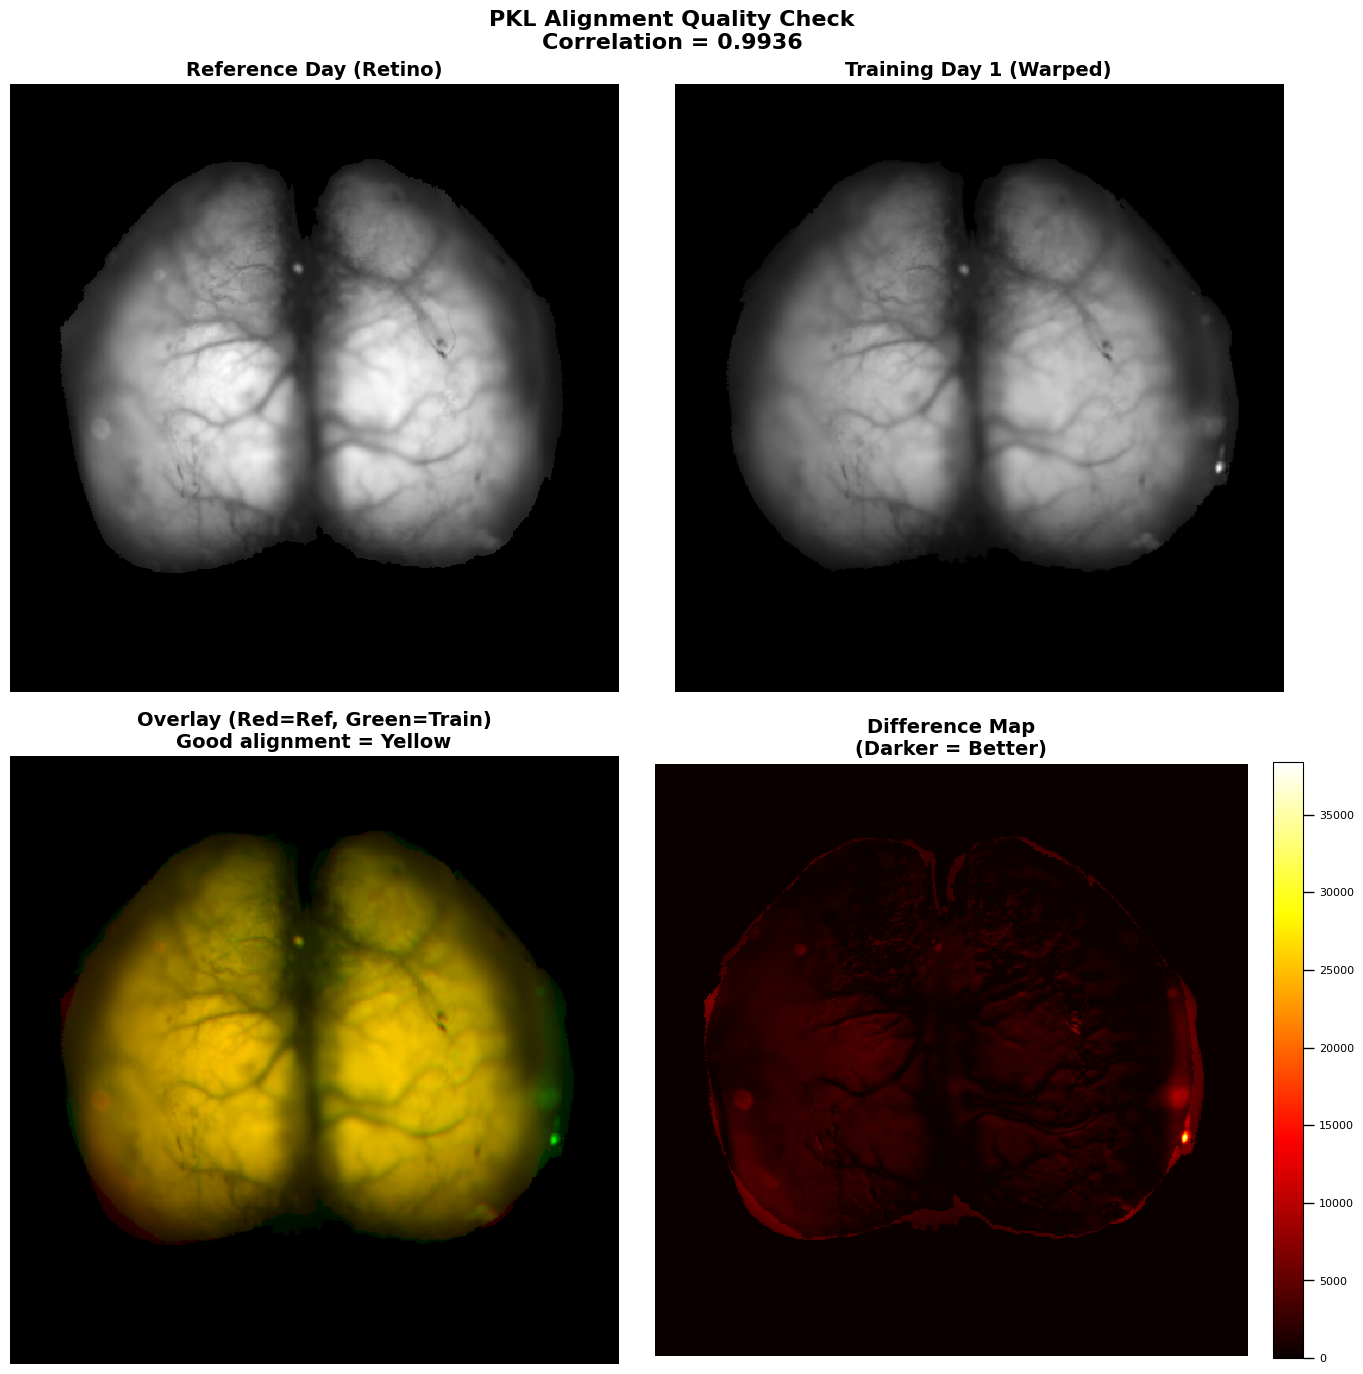


📈 ALIGNMENT QUALITY ASSESSMENT
Correlation coefficient: 0.9936

✅ EXCELLENT - PKL alignment is very good!
   → CCF可以准确应用

💡 Tips:
   • 查看叠加图（左下），黄色区域越多越好
   • 查看差异图（右下），黑色区域越多越好
   • 如果对齐不好，需要回到跨天对齐步骤重新做


In [65]:
#!/usr/bin/env python3
"""
简单检查PKL文件的对齐质量
"""

import numpy as np
import matplotlib.pyplot as plt
import pickle
from skimage.transform import AffineTransform, warp

# ==================== 配置区 ====================
# 修改这里的路径
alignment_pkl = "/home/lsh/Data_attention/Transfer learning/DATA_linshu/A095/widefield_alignment/wf_alignment_A095.pkl"

ref_img_path = "/home/lsh/Data_attention/Transfer learning/DATA_linshu/A095/retino/process/imavg_blue.npy"
train_img_path = "/home/lsh/Data_attention/Transfer learning/DATA_linshu/A095/20250903/process/imavg_blue.npy"
target_day = 1  # 训练日对应的day编号

output_path = "/home/lsh/Data_attention/Transfer learning/DATA_linshu/A095/20250903/process/pkl_alignment_check.png"
# ===============================================


def check_pkl_alignment(alignment_pkl, ref_img_path, train_img_path, target_day, output_path):
    """检查PKL对齐质量"""
    
    # 1. 加载数据
    print("📂 Loading data...")
    with open(alignment_pkl, 'rb') as f:
        alignment_data = pickle.load(f)
    
    ref_img = np.load(ref_img_path)
    train_img = np.load(train_img_path)
    
    print(f"   Reference image shape: {ref_img.shape}")
    print(f"   Training image shape: {train_img.shape}")
    
    # 2. 获取变换矩阵
    print(f"\n🔄 Applying transformation for day {target_day}...")
    tform_matrix = alignment_data['day_tform'][target_day]
    tform = AffineTransform(matrix=tform_matrix)
    
    print(f"   Transformation matrix:")
    print(tform_matrix)
    
    # 3. 将训练日图像变换到参考日
    print("\n🎨 Warping training day image to reference day...")
    train_warped = warp(train_img, tform.inverse, 
                        output_shape=ref_img.shape,
                        preserve_range=True).astype(ref_img.dtype)
    
    # 4. 计算相关系数
    correlation = np.corrcoef(ref_img.flatten(), train_warped.flatten())[0, 1]
    
    # 5. 可视化
    print("\n📊 Creating visualization...")
    fig, axes = plt.subplots(2, 2, figsize=(14, 14))
    
    # 原始参考日图像
    axes[0, 0].imshow(ref_img, cmap='gray')
    axes[0, 0].set_title('Reference Day (Retino)', fontsize=14, fontweight='bold')
    axes[0, 0].axis('off')
    
    # 变换后的训练日图像
    axes[0, 1].imshow(train_warped, cmap='gray')
    axes[0, 1].set_title(f'Training Day {target_day} (Warped)', fontsize=14, fontweight='bold')
    axes[0, 1].axis('off')
    
    # 叠加图（红绿）
    overlay = np.zeros((*ref_img.shape, 3))
    ref_norm = (ref_img - ref_img.min()) / (ref_img.max() - ref_img.min())
    train_norm = (train_warped - train_warped.min()) / (train_warped.max() - train_warped.min())
    overlay[:, :, 0] = ref_norm  # 红色通道 = 参考日
    overlay[:, :, 1] = train_norm  # 绿色通道 = 训练日
    
    axes[1, 0].imshow(overlay)
    axes[1, 0].set_title('Overlay (Red=Ref, Green=Train)\nGood alignment = Yellow', 
                         fontsize=14, fontweight='bold')
    axes[1, 0].axis('off')
    
    # 差异图
    diff = np.abs(ref_img.astype(float) - train_warped.astype(float))
    im = axes[1, 1].imshow(diff, cmap='hot')
    axes[1, 1].set_title('Difference Map\n(Darker = Better)', fontsize=14, fontweight='bold')
    axes[1, 1].axis('off')
    plt.colorbar(im, ax=axes[1, 1], fraction=0.046, pad=0.04)
    
    # 添加总体评估
    fig.suptitle(f'PKL Alignment Quality Check\nCorrelation = {correlation:.4f}', 
                 fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f"   Saved to: {output_path}")
    plt.show()
    
    # 6. 评估结果
    print("\n" + "="*60)
    print("📈 ALIGNMENT QUALITY ASSESSMENT")
    print("="*60)
    print(f"Correlation coefficient: {correlation:.4f}")
    print()
    
    if correlation > 0.85:
        print("✅ EXCELLENT - PKL alignment is very good!")
        print("   → CCF可以准确应用")
    elif correlation > 0.75:
        print("🟡 GOOD - PKL alignment is acceptable")
        print("   → CCF基本可用，但可能有小误差")
    elif correlation > 0.60:
        print("⚠️  FAIR - PKL alignment is marginal")
        print("   → 建议重新做跨天对齐")
    else:
        print("❌ POOR - PKL alignment is bad!")
        print("   → 必须重新做跨天对齐，当前结果不可用")
    
    print("\n💡 Tips:")
    print("   • 查看叠加图（左下），黄色区域越多越好")
    print("   • 查看差异图（右下），黑色区域越多越好")
    print("   • 如果对齐不好，需要回到跨天对齐步骤重新做")
    print("="*60)
    
    return correlation


if __name__ == "__main__":
    correlation = check_pkl_alignment(
        alignment_pkl,
        ref_img_path, 
        train_img_path,
        target_day,
        output_path
    )


 Batch CCF Mapping for A095

 Loading config from: /home/lsh/WF_GoNogo/config/A095_config.yaml
   ✓ Base dir: /home/lsh/Data_attention/Transfer learning/DATA_linshu
   ✓ Reference day: retino

 Loading alignment data from: /home/lsh/Data_attention/Transfer learning/DATA_linshu/A095/widefield_alignment/wf_alignment_A095.pkl

 Sessions to process (11):
   - retino
   - 20250901
   - 20250902
   - 20250903
   - 20250904
   - 20250905
   - 20250827
   - 20250828
   - 20250829
   - 20250923
   - 20250924

 Reference CCF JSON: /home/lsh/Data_attention/Transfer learning/DATA_linshu/A095/retino/process/20250906-185140-wfield/ccf_transform.json

Processing each session...

[1/11] Processing retino...
Skipping (already exists)

[2/11] Processing 20250901...
Skipping (already exists)

[3/11] Processing 20250902...
Skipping (already exists)

[4/11] Processing 20250903...
Skipping (already exists)

[5/11] Processing 20250904...
Skipping (already exists)

[6/11] Processing 20250905...
Skipping (alr

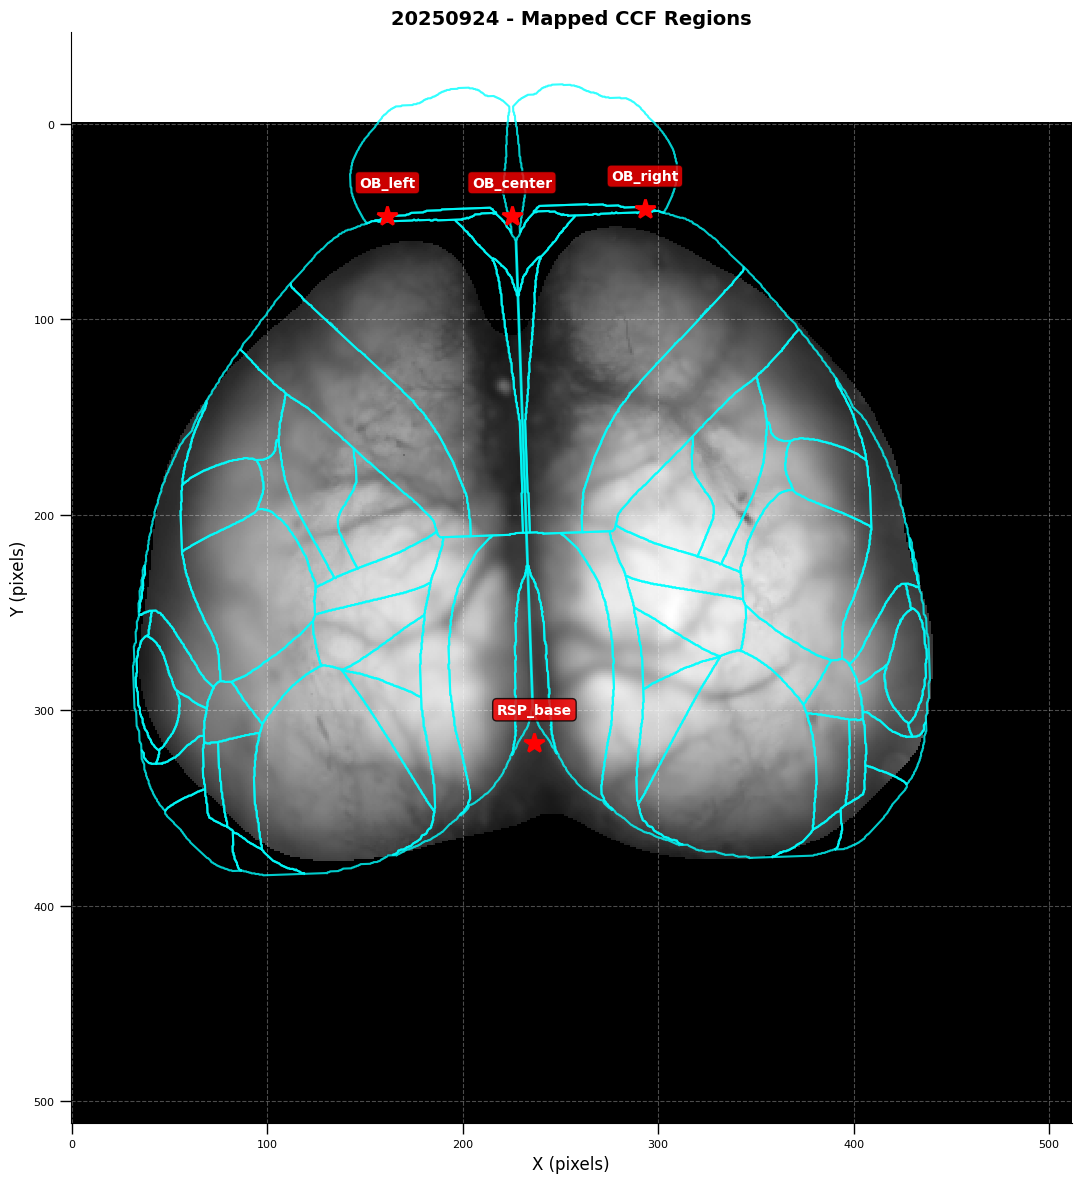


 CCF Mapping Complete for 20250924!


 Batch Processing Summary
 Success: 1/11
Skipped: 10/11



In [1]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from skimage.transform import AffineTransform
from wfield import allen_load_reference, allen_transform_regions
import pandas as pd
import yaml
from pathlib import Path


def load_config(config_path):
    """加载YAML配置文件"""
    with open(config_path, 'r') as f:
        return yaml.safe_load(f)


def map_ccf_to_training_day_v2(ccf_json_path, alignment_pkl_path, target_date, 
                               train_img=None, save_dir=None, visualize=True):
    """
    将Reference Day的CCF配准映射到Training Day (使用日期格式)
    
    Parameters
    ----------
    ccf_json_path : str
        Reference day的CCF配准文件路径
    alignment_pkl_path : str
        跨天对齐文件
    target_date : str
        目标训练日的日期 (格式: 'yyyy-mm-dd' 或 'yyyymmdd')
    train_img : ndarray, optional
        训练日的图像用于可视化
    save_dir : str, optional
        保存结果的目录
    visualize : bool
        是否可视化结果
        
    Returns
    -------
    results : dict
        包含映射后的CCF区域和变换信息
    """
    
    print("="*70)
    print(f" Mapping CCF to {target_date}")
    print("="*70)
    
    # ========================================================================
    # 1. 加载CCF配准数据 (Reference Day)
    # ========================================================================
    print("\n Loading CCF alignment from reference day...")
    with open(ccf_json_path, 'r') as f:
        ccf_data = json.load(f)
    
    M_ref_array = np.array(ccf_data['transform'])
    M_ref = AffineTransform(matrix=M_ref_array)
    resolution = ccf_data['resolution']
    bregma_offset = np.array(ccf_data['bregma_offset'])
    landmarks_ref = ccf_data['landmarks']
    landmarks_match_ref = ccf_data['landmarks_match']
    
    print(f"   ✓ Resolution: {resolution} mm/pixel")
    print(f"   ✓ Landmarks: {len(landmarks_match_ref['name'])}")
    
    # ========================================================================
    # 2. 加载跨天对齐数据
    # ========================================================================
    print(f"\n Loading cross-day alignment for {target_date}...")
    with open(alignment_pkl_path, 'rb') as f:
        alignment_data = pickle.load(f)
    
    reference_day = alignment_data.get('reference_day', 'retino')
    
    # 检查是否是reference day本身
    if target_date == reference_day:
        print(f"Target date is reference day - using identity transform")
        tform_to_train = AffineTransform()  # Identity
        use_inverse = False
    else:
        # 从新格式读取
        if 'alignments' not in alignment_data:
            raise ValueError(f"PKL file doesn't have 'alignments' key. Wrong format?")
        
        if target_date not in alignment_data['alignments']:
            available_dates = list(alignment_data['alignments'].keys())
            raise ValueError(f"Date '{target_date}' not found in alignment file.\n"
                           f"Available dates: {available_dates}")
        
        tform_matrix = alignment_data['alignments'][target_date]['tform']
        print(f"   ✓ Transform matrix loaded for {target_date}")
        
        # 使用逆变换 (PKL存的是 Training→Reference, 我们需要 Reference→Training)
        tform_base = AffineTransform(matrix=tform_matrix)
        tform_to_train = tform_base.inverse
        use_inverse = True
        print(f"   ✓ Using INVERSE transform (Ref → Train)")
    
    M_to_train = tform_to_train.params
    
    # ========================================================================
    # 3. 加载Allen CCF参考区域
    # ========================================================================
    print("\n Loading Allen CCF reference regions...")
    ccf_regions_reference, proj, brain_outline = allen_load_reference('dorsal_cortex')
    print(f"   ✓ Loaded {len(ccf_regions_reference)} CCF regions")
    
    # ========================================================================
    # 4. 将CCF区域映射到Training Day
    # ========================================================================
    print(f"\n Mapping CCF regions to {target_date}...")
    
    # Step 1: 映射到Reference day的图像空间
    ccf_regions_ref_img = allen_transform_regions(
        M_ref,
        ccf_regions_reference,
        resolution=resolution,
        bregma_offset=bregma_offset
    )
    
    # Step 2: 映射到Training day
    ccf_regions_train = []
    
    for i, region in ccf_regions_ref_img.iterrows():
        region_train = region.copy()
        
        # 变换左半球
        if region['left_x'] is not None and len(region['left_x']) > 0:
            coords_left = np.column_stack([region['left_x'], region['left_y']])
            coords_left_train = tform_to_train(coords_left)
            region_train['left_x'] = coords_left_train[:, 0].tolist()
            region_train['left_y'] = coords_left_train[:, 1].tolist()
            
            if region['left_center'] is not None:
                center_train = tform_to_train(np.array([region['left_center']]))
                region_train['left_center'] = center_train[0].tolist()
        
        # 变换右半球
        if region['right_x'] is not None and len(region['right_x']) > 0:
            coords_right = np.column_stack([region['right_x'], region['right_y']])
            coords_right_train = tform_to_train(coords_right)
            region_train['right_x'] = coords_right_train[:, 0].tolist()
            region_train['right_y'] = coords_right_train[:, 1].tolist()
            
            if region['right_center'] is not None:
                center_train = tform_to_train(np.array([region['right_center']]))
                region_train['right_center'] = center_train[0].tolist()
        
        ccf_regions_train.append(region_train)
    
    ccf_regions_train_df = pd.DataFrame(ccf_regions_train)
    print(f"   ✓ Mapped {len(ccf_regions_train_df)} regions")
    
    # ========================================================================
    # 5. 变换地标点
    # ========================================================================
    print("\n Mapping landmark points...")
    landmarks_train = {}
    
    for i, name in enumerate(landmarks_match_ref['name']):
        x_ref = landmarks_match_ref['x'][i]
        y_ref = landmarks_match_ref['y'][i]
        
        coord_train = tform_to_train(np.array([[x_ref, y_ref]]))
        landmarks_train[name] = {
            'x': float(coord_train[0, 0]),
            'y': float(coord_train[0, 1])
        }
    
    print(f"   ✓ Mapped {len(landmarks_train)} landmarks")
    
    # 验证地标点是否在图像范围内
    if train_img is not None:
        h, w = train_img.shape
        in_bounds = sum(1 for coords in landmarks_train.values() 
                       if 0 <= coords['x'] < w and 0 <= coords['y'] < h)
        print(f"   ✓ {in_bounds}/{len(landmarks_train)} landmarks in image bounds")
    
    # ========================================================================
    # 6. 保存结果
    # ========================================================================
    if save_dir is not None:
        print(f"\n Saving results to {save_dir}...")
        os.makedirs(save_dir, exist_ok=True)
        
        # 保存CCF区域
        ccf_save_path = os.path.join(save_dir, 'ccf_regions.pkl')
        ccf_regions_train_df.to_pickle(ccf_save_path)
        print(f"   ✓ CCF regions: {ccf_save_path}")
        
        # 保存地标点
        landmarks_save_path = os.path.join(save_dir, 'ccf_landmarks.json')
        with open(landmarks_save_path, 'w') as f:
            json.dump(landmarks_train, f, indent=2)
        print(f"   ✓ Landmarks: {landmarks_save_path}")
        
        # 保存完整数据
        full_data = {
            'ccf_regions': ccf_regions_train_df.to_dict('records'),
            'landmarks': landmarks_train,
            'transform_to_train': M_to_train.tolist(),
            'used_inverse': use_inverse,
            'resolution': resolution,
            'target_date': target_date,
            'reference_day': reference_day,
            'reference_ccf': ccf_json_path,
            'alignment_pkl': alignment_pkl_path
        }
        full_save_path = os.path.join(save_dir, 'ccf_transform.json')
        with open(full_save_path, 'w') as f:
            json.dump(full_data, f, indent=2)
        print(f"   ✓ Full data: {full_save_path}")
    
    # ========================================================================
    # 7. 可视化
    # ========================================================================
    if visualize and train_img is not None:
        print("\n Creating visualization...")
        
        fig, ax = plt.subplots(figsize=(12, 12), dpi=100)
        
        # 显示训练日图像
        ax.imshow(train_img, cmap='gray')
        
        # 绘制CCF区域
        key_regions = ['V1', 'V2L', 'V2M', 'RSP', 'M1', 'M2', 'S1']
        
        for i, region in ccf_regions_train_df.iterrows():
            # 左半球
            if region['left_x'] is not None and len(region['left_x']) > 0:
                ax.plot(region['left_x'], region['left_y'],
                       'cyan', lw=1.5, alpha=0.8)
                
                if region['left_center'] is not None and region['acronym'] in key_regions:
                    center = region['left_center']
                    ax.text(center[0], center[1], region['acronym'],
                           color='yellow', ha='center', va='center',
                           fontsize=9, fontweight='bold',
                           bbox=dict(boxstyle='round,pad=0.3',
                                    facecolor='black', alpha=0.7))
            
            # 右半球
            if region['right_x'] is not None and len(region['right_x']) > 0:
                ax.plot(region['right_x'], region['right_y'],
                       'cyan', lw=1.5, alpha=0.8)
                
                if region['right_center'] is not None and region['acronym'] in key_regions:
                    center = region['right_center']
                    ax.text(center[0], center[1], region['acronym'],
                           color='yellow', ha='center', va='center',
                           fontsize=9, fontweight='bold',
                           bbox=dict(boxstyle='round,pad=0.3',
                                    facecolor='black', alpha=0.7))
        
        # 绘制地标点
        for name, coords in landmarks_train.items():
            ax.plot(coords['x'], coords['y'], 'r*', ms=15, mew=2)
            ax.text(coords['x'], coords['y'] - 15, name,
                   color='white', ha='center', fontsize=10,
                   fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3',
                            facecolor='red', alpha=0.8))
        
        ax.set_title(f'{target_date} - Mapped CCF Regions', 
                    fontsize=14, fontweight='bold')
        ax.set_xlabel('X (pixels)', fontsize=12)
        ax.set_ylabel('Y (pixels)', fontsize=12)
        ax.grid(True, alpha=0.3, color='white', linestyle='--')
        
        plt.tight_layout()
        
        if save_dir is not None:
            fig_path = os.path.join(save_dir, 'ccf_mapping_visualization.png')
            plt.savefig(fig_path, dpi=150, bbox_inches='tight')
            print(f"   ✓ Figure: {fig_path}")
        
        plt.show()
        plt.close()
    
    # ========================================================================
    # 8. 返回结果
    # ========================================================================
    results = {
        'ccf_regions': ccf_regions_train_df,
        'landmarks': landmarks_train,
        'transform_to_train': M_to_train,
        'used_inverse': use_inverse,
        'resolution': resolution,
        'bregma_offset': bregma_offset,
        'target_date': target_date,
        'reference_day': reference_day
    }
    
    print("\n" + "="*70)
    print(f" CCF Mapping Complete for {target_date}!")
    print("="*70 + "\n")
    
    return results


def batch_map_ccf_across_days(animal, config_path=None, sessions=None, 
                               visualize=True, skip_existing=False):
    """
    批量将CCF映射到所有已对齐的天
    
    Parameters
    ----------
    animal : str
        动物ID (例如: 'A095')
    config_path : str, optional
        配置文件路径。如果为None，自动构造为 /home/lsh/WF_GoNogo/config/{animal}_config.yaml
    sessions : list, optional
        要处理的session日期列表。如果为None，自动从alignment.pkl读取
    visualize : bool
        是否为每个日期生成可视化图
    skip_existing : bool
        是否跳过已经存在ccf_transform.json的日期
        
    Returns
    -------
    results : dict
        每个日期的映射结果 {date: results_dict}
    """
    
    print("\n" + "="*80)
    print(f" Batch CCF Mapping for {animal}")
    print("="*80)
    
    # ========================================================================
    # 1. 加载配置
    # ========================================================================
    if config_path is None:
        config_path = f"/home/lsh/WF_GoNogo/config/{animal}_config.yaml"
    
    print(f"\n Loading config from: {config_path}")
    config = load_config(config_path)
    
    base_dir = config['base_dir']
    reference_day = config.get('alignment', {}).get('reference_day')
    
    if reference_day is None:
        raise ValueError(f"No reference_day specified in config!")
    
    print(f"   ✓ Base dir: {base_dir}")
    print(f"   ✓ Reference day: {reference_day}")
    
    # ========================================================================
    # 2. 定位alignment.pkl文件
    # ========================================================================
    # 假设alignment.pkl在 {base_dir}/{animal}/widefield_alignment/wf_alignment_{animal}.pkl
    alignment_pkl_path = f"{base_dir}/{animal}/widefield_alignment/wf_alignment_{animal}.pkl"
    
    if not os.path.exists(alignment_pkl_path):
        raise FileNotFoundError(f"Alignment file not found: {alignment_pkl_path}")
    
    print(f"\n Loading alignment data from: {alignment_pkl_path}")
    with open(alignment_pkl_path, 'rb') as f:
        alignment_data = pickle.load(f)
    
    # ========================================================================
    # 3. 确定要处理的日期
    # ========================================================================
    if sessions is None:
        # 从alignment.pkl读取所有已对齐的日期
        if 'alignments' in alignment_data:
            sessions = list(alignment_data['alignments'].keys())
        else:
            raise ValueError("No 'alignments' key in pkl file. Wrong format?")
    
    print(f"\n Sessions to process ({len(sessions)}):")
    for session in sessions:
        print(f"   - {session}")
    
    # ========================================================================
    # 4. 定位reference day的CCF JSON
    # ========================================================================
    # 构造路径: {base_dir}/{animal}/{reference_day}/process/
    ref_process_path = config["paths"]["process"].format(
        base_dir=base_dir, 
        mouse_id=animal, 
        session=reference_day
    )
    
    # 查找ccf_transform.json
    ccf_json_candidates = list(Path(ref_process_path).glob("*/ccf_transform.json"))
    
    if len(ccf_json_candidates) == 0:
        raise FileNotFoundError(f"No ccf_transform.json found in {ref_process_path}")
    elif len(ccf_json_candidates) > 1:
        print(f" Multiple ccf_transform.json found, using first one")
    
    ccf_json_path = str(ccf_json_candidates[0])
    print(f"\n Reference CCF JSON: {ccf_json_path}")
    
    # ========================================================================
    # 5. 批量处理每个日期
    # ========================================================================
    print("\n" + "="*80)
    print("Processing each session...")
    print("="*80)
    
    all_results = {}
    success_count = 0
    skip_count = 0
    error_count = 0
    
    for i, session in enumerate(sessions, 1):
        print(f"\n[{i}/{len(sessions)}] Processing {session}...")
        
        try:
            # 构造该session的process路径
            session_process_path = config["paths"]["process"].format(
                base_dir=base_dir,
                mouse_id=animal,
                session=session
            )
            
            # 检查是否已存在
            ccf_output_path = os.path.join(session_process_path, "ccf_transform.json")
            if skip_existing and os.path.exists(ccf_output_path):
                print(f"Skipping (already exists)")
                skip_count += 1
                continue
            
            # 加载该session的图像
            img_path = os.path.join(session_process_path, "imavg_blue.npy")
            if not os.path.exists(img_path):
                print(f"Image not found: {img_path}, skipping")
                error_count += 1
                continue
            
            train_img = np.load(img_path)
            print(f"   ✓ Loaded image: {train_img.shape}")
            
            # 执行映射
            results = map_ccf_to_training_day_v2(
                ccf_json_path=ccf_json_path,
                alignment_pkl_path=alignment_pkl_path,
                target_date=session,
                train_img=train_img,
                save_dir=session_process_path,
                visualize=visualize
            )
            
            all_results[session] = results
            success_count += 1
            
        except Exception as e:
            print(f"Error processing {session}: {e}")
            error_count += 1
            import traceback
            traceback.print_exc()
    
    # ========================================================================
    # 6. 总结
    # ========================================================================
    print("\n" + "="*80)
    print(" Batch Processing Summary")
    print("="*80)
    print(f" Success: {success_count}/{len(sessions)}")
    if skip_count > 0:
        print(f"Skipped: {skip_count}/{len(sessions)}")
    if error_count > 0:
        print(f"Errors: {error_count}/{len(sessions)}")
    print("="*80 + "\n")
    
    return all_results


# ============================================================================
# 使用示例
# ============================================================================
if __name__ == "__main__":
    
    # 方法1: 批量处理所有已对齐的日期
    results = batch_map_ccf_across_days(
        animal='A095',
        visualize=True,
        skip_existing=True  # 设为True可以跳过已处理的
    )
    
    # 方法2: 只处理指定的日期
    # results = batch_map_ccf_across_days(
    #     animal='A095',
    #     sessions=['20250903', '20250904'],
    #     visualize=True
    # )
    
    # 方法3: 手动处理单个日期
    # ccf_json = "/path/to/reference/ccf_transform.json"
    # alignment_pkl = "/path/to/wf_alignment_A095.pkl"
    # train_img = np.load("/path/to/20250903/imavg_blue.npy")
    # save_dir = "/path/to/20250903/process"
    # 
    # result = map_ccf_to_training_day_v2(
    #     ccf_json_path=ccf_json,
    #     alignment_pkl_path=alignment_pkl,
    #     target_date='20250903',
    #     train_img=train_img,
    #     save_dir=save_dir,
    #     visualize=True
    # )